In [1]:
import matplotlib.pyplot as plt
import pandas as pd
BSSE_by_FF_distance = pd.read_csv("BSSE_by_FF_distance.csv")

In [2]:
BSSE_by_FF_distance.columns

Index(['FF_distance', 'BSSE_A', 'BSSE_B'], dtype='object')

Text(0, 0.5, 'Energy (kcal/mol)')

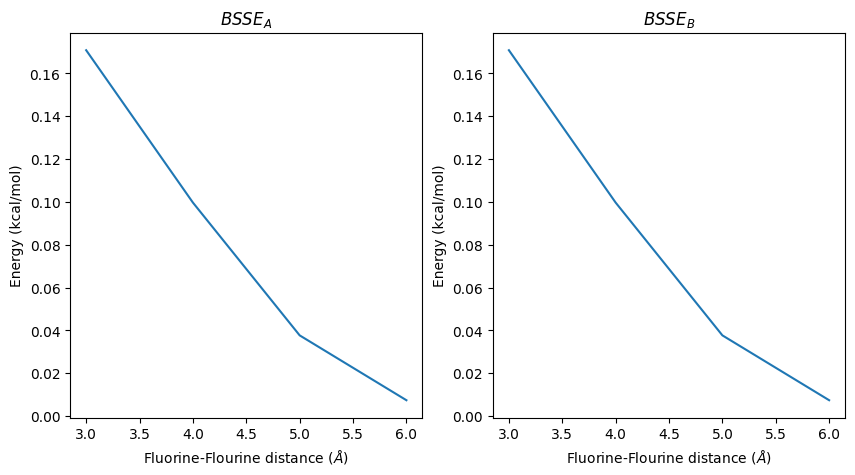

In [22]:
fig, ax = plt.subplots(1,2, figsize=(10, 5))

ax[0].plot(BSSE_by_FF_distance["FF_distance"], BSSE_by_FF_distance["BSSE_A"] * 627.5096)
ax[1].plot(BSSE_by_FF_distance["FF_distance"], BSSE_by_FF_distance["BSSE_B"]* 627.5096)
ax[0].set_title(r"$BSSE_A$")
ax[1].set_title(r"$BSSE_B$")
ax[0].set_xlabel(r"Fluorine-Flourine distance $(\AA)$")
ax[1].set_xlabel(r"Fluorine-Flourine distance $(\AA)$")
ax[0].set_ylabel(r"Energy (kcal/mol)")
ax[1].set_ylabel(r"Energy (kcal/mol)")

In [1]:
geometry = [
    ['H 0.0 0.0 -1', 
    'F 0.0 0.0 0.0'],
    ['F 0.0 0.0 1',
    "H 0.0 0.0 2"]
  ]

In [2]:
import py3Dmol
from IPython.display import display, HTML
view_block = "4\nDimer\n"+ "\n".join([*geometry[0], *geometry[1]])
view = py3Dmol.view(width=400, height=400)
view.addModel(view_block, 'xyz')
view.addBonds([
    {'from': 0, 'to': 1, 'order': 1},
    {'from': 2, 'to': 3, 'order': 1},
])
view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
view.zoomTo()

# Instead of view.show(), use:
display(HTML(view._make_html()))


In [6]:
make_diagram(geometry, "dimer.html")

In [4]:
from rdkit import Chem
from rdkit.Chem import AllChem
import py3Dmol
from IPython.display import display, HTML

bonds = [
    (0, 1, Chem.BondType.SINGLE),
    (2, 3, Chem.BondType.SINGLE),
]
mol = Chem.RWMol()
for row in [*geometry[0], *geometry[1]]:
    atom_symbol = row.split()[0]
    mol.AddAtom(Chem.Atom(atom_symbol))
for i, j, bond_type in bonds:
    mol.AddBond(i, j, bond_type)

# Add conformer with coordinates
conf = Chem.Conformer(mol.GetNumAtoms())
for i, row in enumerate([*geometry[0], *geometry[1]]):
    _, x, y, z = row.split()
    conf.SetAtomPosition(i, Chem.rdGeometry.Point3D(float(x), float(y), float(z)))
mol.AddConformer(conf)

mol_block = Chem.MolToMolBlock(mol)

view = py3Dmol.view(width=400, height=400)
view.addModel(mol_block, 'mol')
view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
view.zoomTo()
display(HTML(view._make_html()))


In [8]:
import pandas as pd
data = pd.read_csv("BSSE_by_FF_distance.csv", multiindex=False)

TypeError: read_csv() got an unexpected keyword argument 'multiindex'

In [29]:
xs = []
ys = []
zs = []
BSSE_As = []
BSSE_Bs = []
with open("BSSE_by_FF_distance.csv", "r") as f:
    next(f)
    for line in f:
      _, x,y,z, BSSE_A, BSSE_B = line.strip().split(",")
      x = float(x.replace("(", ""))
      y = float(y)
      z = float(z.replace(")", ""))
      xs.append(x)
      ys.append(y)
      zs.append(z)
      BSSE_As.append(float(BSSE_A))
      BSSE_Bs.append(float(BSSE_B))
data = pd.DataFrame({"x": xs, "y": ys, "z": zs, "BSSE_A": BSSE_As, "BSSE_B": BSSE_Bs})
      

In [30]:
data.to_csv("BSSE_by_FF_distance.csv", index=False)

In [31]:
data

,x,y,z,BSSE_A,BSSE_B
0,1.0,1.0,1.0,5.006870e-04,0.001219
1,1.0,1.0,2.0,1.696498e-04,0.000870
2,1.0,1.0,3.0,1.439137e-04,0.000846
3,1.0,1.0,4.0,9.235194e-05,0.000790
4,1.0,2.0,1.0,1.042225e-04,0.000799
...,...,...,...,...,...
59,4.0,3.0,4.0,1.522619e-06,0.000692
60,4.0,4.0,1.0,2.247397e-06,0.000693
61,4.0,4.0,2.0,1.665859e-06,0.000692
62,4.0,4.0,3.0,1.049837e-06,0.000691


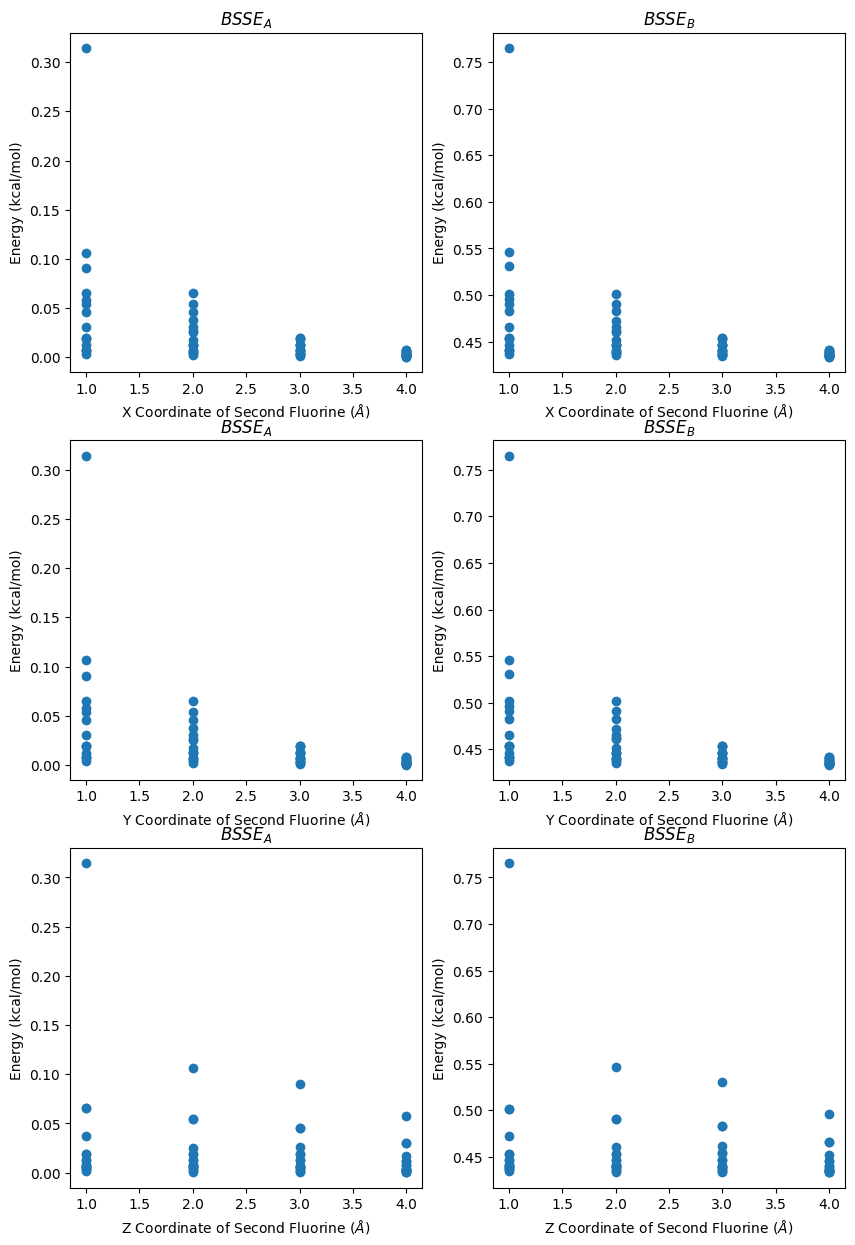

In [37]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3,2, figsize=(10, 15))
for i, dim in enumerate(["x", "y", "z"]):
  ax[i][0].scatter(data[dim], data["BSSE_A"] * 627.5096)
  ax[i][1].scatter(data[dim], data["BSSE_B"]* 627.5096)
  ax[i][0].set_title(r"$BSSE_A$")
  ax[i][1].set_title(r"$BSSE_B$")
  ax[i][0].set_xlabel(f"{dim.upper()} Coordinate of Second Fluorine"+ r" $(\AA)$")
  ax[i][1].set_xlabel(f"{dim.upper()} Coordinate of Second Fluorine"+ r" $(\AA)$")
  ax[i][0].set_ylabel(r"Energy (kcal/mol)")
  ax[i][1].set_ylabel(r"Energy (kcal/mol)")